# EDA — RQ1: Transition talk vs. fossil-fuel share of the top fossil-fuel producers

**RQ1 (exploratory, SDG 13):** What is the correlation between how often the world's top fossil-fuel-producing
countries mention the energy transition in their UN General Debate speeches and the share of fossil fuels in their
energy consumption since the 2015 Paris Agreement?

This notebook combines everything needed to answer RQ1 in one place:

1. Load the speech features and the external country-year panel
2. Select the top fossil-fuel-producing countries (production × fossil rents)
3. Merge the speeches with the fossil-fuel share of primary energy
4. Descriptive statistics
5. Transition talk over time
6. Country-level summary table
7. Fossil-fuel share trajectories per country
8. Between-country correlation (main result) and robustness checks
9. Within-country (year-to-year) check
10. Summary

**Inputs** (all produced by earlier notebooks):
- `datasets/speeches_advanced_clean.parquet` — transition mention counts per speech (`preprocessing_advanced.ipynb`)
- `datasets/speeches_simple_clean.parquet` — word count per speech (`preprocessing_simple.ipynb`)
- `datasets/prepared_data/master_panel_country_year.csv` — World Bank rents + OWID energy mix and production (`external_data.ipynb`)

**Outputs:** figures in `figures/` (PNG + PDF for the report) and tables in `datasets/prepared_data/`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = '../datasets'
PREP_DIR = '../datasets/prepared_data'
FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)

PERIOD_START = 2015              # Paris Agreement
SELECTION_YEARS = (2015, 2021)   # World Bank rents are only complete up to 2021

# One accent colour for the countries we study, grey for context
ACCENT = '#2a78d6'
CONTEXT = '#898781'
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
AXIS = '#c3c2b7'
GRID = '#e1e0d9'

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'axes.edgecolor': AXIS,
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlecolor': INK,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'axes.axisbelow': True,
    'grid.color': GRID,
    'grid.linewidth': 0.6,
    'xtick.color': INK_SECONDARY,
    'ytick.color': INK_SECONDARY,
    'legend.frameon': False,
    'lines.linewidth': 2,
})


def save_fig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f'{name}.png'))
    fig.savefig(os.path.join(FIG_DIR, f'{name}.pdf'))

## Step 1 — Load the data

- **Speeches** (2015 onward, 2,128 speeches): one row per country-year with the number of energy-transition mentions
  found by the 22 regular expressions in `preprocessing_advanced.ipynb`. We join the word count from the simple
  preprocessing so that mentions can be expressed relative to speech length.
- **Panel**: one row per country-year with fossil rents (% of GDP, World Bank), fossil-fuel production (TWh, OWID) and
  the fossil-fuel share of primary energy consumption (%, OWID).

In [2]:
panel = pd.read_csv(f'{PREP_DIR}/master_panel_country_year.csv')

speech_features = pd.read_parquet(f'{DATA_DIR}/speeches_advanced_clean.parquet')
word_counts = pd.read_parquet(f'{DATA_DIR}/speeches_simple_clean.parquet')[['WordCount']]

speeches = (speech_features[['Country or Area', 'transition_mention_count']]
            .join(word_counts, how='left')
            .reset_index()
            .rename(columns={'ISO-alpha3 Code': 'iso3', 'Country or Area': 'speech_country'}))

names = panel.drop_duplicates('iso3').set_index('iso3')['country']

print('Panel:', panel.shape, f"({panel['Year'].min()}-{panel['Year'].max()})")
print('Speeches since 2015:', speeches.shape, f"({speeches['iso3'].nunique()} countries)")
print('Speeches without a word count:', speeches['WordCount'].isna().sum())

Panel: (14383, 13) (1960-2025)
Speeches since 2015: (2128, 5) (196 countries)
Speeches without a word count: 0


## Step 2 — Select the top fossil-fuel-producing countries

We want countries whose economies are both **large fossil-fuel producers** and **dependent on fossil fuels**, since
for them the energy transition is a real economic transformation. We use two criteria, each measured as the mean over
2015–2021 (the World Bank rent data is only complete up to 2021, so both criteria use the same window):

- **Production** (OWID): mean total coal + oil + gas production in TWh. Top quartile of the 73 countries OWID covers.
- **Rent dependence** (World Bank): mean total fossil-fuel rents as % of GDP. Top quartile of all 202 countries.

A country is selected if it is in the top quartile on **both**. Note that rents measure how much of the economy
depends on fossil-fuel extraction, not exports as such.

In [3]:
window = panel[panel['Year'].between(*SELECTION_YEARS)]

mean_rents = window.groupby('iso3')['total_fossil_rents_pct_gdp'].mean().dropna()
mean_production = window.groupby('iso3')['total_production_twh'].mean().dropna()

rents_cutoff = mean_rents.quantile(0.75)
production_cutoff = mean_production.quantile(0.75)

rent_dependent = set(mean_rents[mean_rents >= rents_cutoff].index)
big_producers = set(mean_production[mean_production >= production_cutoff].index)
top_iso3 = sorted(big_producers & rent_dependent)

print(f'Production cutoff (top quartile of {len(mean_production)} countries): '
      f'{production_cutoff:,.0f} TWh -> {len(big_producers)} countries')
print(f'Rents cutoff (top quartile of {len(mean_rents)} countries): '
      f'{rents_cutoff:.2f}% of GDP -> {len(rent_dependent)} countries')
print(f'Both criteria: {len(top_iso3)} countries')
print('Large producers that are NOT rent-dependent:', sorted(big_producers - rent_dependent))

Production cutoff (top quartile of 73 countries): 1,643 TWh -> 19 countries
Rents cutoff (top quartile of 202 countries): 1.40% of GDP -> 51 countries
Both criteria: 15 countries
Large producers that are NOT rent-dependent: ['CAN', 'CHN', 'IND', 'USA']


In [4]:
selection = pd.DataFrame({
    'country': names.reindex(top_iso3),
    'mean_production_twh': mean_production.reindex(top_iso3).round(0),
    'mean_rents_pct_gdp': mean_rents.reindex(top_iso3).round(2),
}).sort_values('mean_production_twh', ascending=False)
selection

,country,mean_production_twh,mean_rents_pct_gdp
iso3,,,
RUS,Russian Federation,15255.0,10.18
SAU,Saudi Arabia,7542.0,23.88
AUS,Australia,4977.0,1.91
IRN,"Iran, Islamic Rep.",4408.0,21.99
IDN,Indonesia,4347.0,2.32
QAT,Qatar,2613.0,21.12
IRQ,Iraq,2584.0,38.22
ARE,United Arab Emirates,2567.0,14.98
NOR,Norway,2176.0,5.99


Save the selection in the same format as `eda.ipynb`, because `predictive_modelling.ipynb` reads this file.

In [5]:
is_exporter_df = panel[['iso3', 'country']].drop_duplicates()
is_exporter_df['Is exporter'] = is_exporter_df['iso3'].isin(top_iso3)
is_exporter_df.to_csv(f'{PREP_DIR}/major_exporters.csv', index=False)

print(is_exporter_df['Is exporter'].sum(), 'countries flagged in major_exporters.csv')

15 countries flagged in major_exporters.csv


**Figure 1 — selection.** One point per country that OWID reports production for. The dashed lines are the two
top-quartile cutoffs; the selected countries are the blue points in the top-right corner. The four large producers
bottom-right (China, the US, Canada, India) produce a lot but their economies are too diversified to count as
fossil-fuel dependent. Both axes are logarithmic because production and rents span several orders of magnitude.

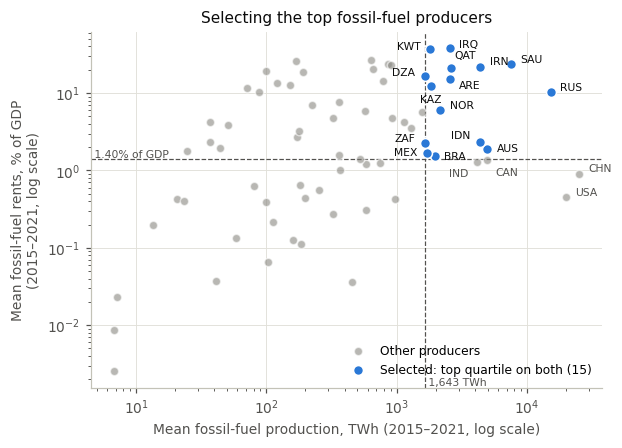

In [6]:
sel = pd.concat([mean_production.rename('production'), mean_rents.rename('rents')], axis=1).dropna()
is_top = sel.index.isin(top_iso3)
not_dependent = sorted(big_producers - rent_dependent)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.grid(True, axis='both')
ax.scatter(sel.loc[~is_top, 'production'], sel.loc[~is_top, 'rents'], s=30, color=CONTEXT, alpha=0.6,
           edgecolor='white', linewidth=1, label='Other producers', zorder=2)
ax.scatter(sel.loc[is_top, 'production'], sel.loc[is_top, 'rents'], s=42, color=ACCENT,
           edgecolor='white', linewidth=1, label=f'Selected: top quartile on both ({is_top.sum()})', zorder=3)
ax.axvline(production_cutoff, color=INK_SECONDARY, lw=0.8, ls='--', zorder=1)
ax.axhline(rents_cutoff, color=INK_SECONDARY, lw=0.8, ls='--', zorder=1)

# Label offsets (points) and alignment, chosen by hand so the labels in the crowded top-right corner don't overlap
label_pos = {
    'KWT': (-6, 2, 'right'), 'IRQ': (6, 2, 'left'), 'DZA': (-6, 2, 'right'), 'KAZ': (0, -9, 'center'),
    'QAT': (2, 8, 'left'), 'ARE': (6, -4, 'left'), 'ZAF': (-6, 3, 'right'), 'MEX': (-6, 0, 'right'),
    'BRA': (6, 0, 'left'), 'IDN': (-6, 4, 'right'), 'AUS': (6, 0, 'left'), 'IND': (-6, -8, 'right'),
    'CAN': (6, -8, 'left'),
}
for iso in top_iso3 + not_dependent:
    dx, dy, ha = label_pos.get(iso, (6, 3, 'left'))
    ax.annotate(iso, (sel.loc[iso, 'production'], sel.loc[iso, 'rents']), xytext=(dx, dy),
                textcoords='offset points', fontsize=7, ha=ha, va='center',
                color=INK if iso in top_iso3 else INK_SECONDARY)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Mean fossil-fuel production, TWh (2015–2021, log scale)')
ax.set_ylabel('Mean fossil-fuel rents, % of GDP\n(2015–2021, log scale)')
ax.text(production_cutoff, ax.get_ylim()[0], f' {production_cutoff:,.0f} TWh', fontsize=7,
        color=INK_SECONDARY, va='bottom')
ax.text(ax.get_xlim()[0], rents_cutoff, f' {rents_cutoff:.2f}% of GDP', fontsize=7,
        color=INK_SECONDARY, va='bottom')
ax.set_title('Selecting the top fossil-fuel producers')
ax.legend(loc='lower right', fontsize=8)

save_fig(fig, 'fig1_selection')
plt.show()

## Step 3 — Merge the speeches with the fossil-fuel share of energy

Transition talk is measured as **mentions per 1,000 words**: a longer speech has more room to mention any topic, so
raw counts would favour long speeches. The outcome is the **fossil-fuel share of primary energy consumption** (%) from
OWID. We use a left join on ISO-3 code and year so that no speech is lost, then check that the merge did not create
duplicates.

In [7]:
speeches['mentions_per_1000_words'] = speeches['transition_mention_count'] / speeches['WordCount'] * 1000
speeches['top_producer'] = speeches['iso3'].isin(top_iso3)

energy_mix = panel[['iso3', 'Year', 'fossil_share_pct']]
df = speeches.merge(energy_mix, on=['iso3', 'Year'], how='left', validate='one_to_one')

assert len(df) == len(speeches)
assert not df.duplicated(['iso3', 'Year']).any()

top = df[df['top_producer']].copy()
print(f"{len(top)} speeches by the {top['iso3'].nunique()} selected countries "
      f"({top['Year'].min()}-{top['Year'].max()})")
print('Speeches by selected countries without a fossil share value:', top['fossil_share_pct'].isna().sum())
top.loc[top['fossil_share_pct'].isna(), ['iso3', 'Year']].groupby('iso3')['Year'].apply(list)

165 speeches by the 15 selected countries (2015-2025)
Speeches by selected countries without a fossil share value: 8


iso3
IRQ    [2015, 2016, 2020, 2021, 2022, 2023, 2024, 2025]
Name: Year, dtype: object

The missing values are all Iraq: OWID only reports Iraq's energy mix for 2017–2019. We keep Iraq, but its fossil share
trend is based on three years only (see the robustness check in Step 8).

In [8]:
df.to_csv(f'{PREP_DIR}/eda_rq1_country_year.csv', index=False)

## Step 4 — Descriptive statistics

First the transition-talk measure, for the selected countries and for all other countries.

In [9]:
def describe_talk(g):
    return {
        'speeches': len(g),
        'countries': g['iso3'].nunique(),
        'mean mentions / 1000 words': g['mentions_per_1000_words'].mean(),
        'std mentions / 1000 words': g['mentions_per_1000_words'].std(),
        'median mentions / 1000 words': g['mentions_per_1000_words'].median(),
        'max mentions / 1000 words': g['mentions_per_1000_words'].max(),
        '% speeches with >= 1 mention': (g['transition_mention_count'] > 0).mean() * 100,
    }


talk_stats = pd.DataFrame({
    'Top producers': describe_talk(df[df['top_producer']]),
    'Other countries': describe_talk(df[~df['top_producer']]),
    'All countries': describe_talk(df),
})
talk_stats.round(2)

,Top producers,Other countries,All countries
speeches,165.00,1963.00,2128.00
countries,15.00,181.00,196.00
mean mentions / 1000 words,0.37,0.33,0.33
std mentions / 1000 words,0.66,0.68,0.68
median mentions / 1000 words,0.00,0.00,0.00
max mentions / 1000 words,3.73,7.82,7.82
% speeches with >= 1 mention,34.55,31.28,31.53


The median is 0 in both groups: about two out of three speeches never mention the energy transition. The distribution
is therefore heavily zero-inflated and right-skewed, which is why we use **Spearman's rank correlation** rather than
Pearson's in Step 8 (it does not assume a linear relationship or normally distributed variables and is less sensitive
to a few extreme values).

Next the outcome: the fossil-fuel share of primary energy for the selected countries, per year.

In [10]:
share = top.dropna(subset=['fossil_share_pct'])
share.groupby('Year')['fossil_share_pct'].agg(['count', 'mean', 'median', 'min', 'max']).round(1)

,count,mean,median,min,max
Year,,,,,
2015,14,92.5,97.8,54.0,100.0
2016,14,92.0,97.5,52.6,100.0
2017,15,92.6,98.4,53.6,100.0
2018,15,92.3,98.6,53.6,100.0
2019,15,92.1,98.3,55.3,100.0
2020,14,90.7,97.2,50.3,100.0
2021,14,90.6,96.4,49.5,100.0
2022,14,90.5,95.1,51.5,100.0
2023,14,90.0,94.5,49.6,100.0


Most of these countries get nearly all their energy from fossil fuels (the yearly median is 94–98%), with Norway and Brazil as
clear exceptions because of their large hydropower share. Because the starting levels differ so much, in the rest of
the analysis we look at the **change** in the fossil share rather than its level.

## Step 5 — Transition talk over time

**Figure 2.** Mean mentions per 1,000 words per year, for the selected countries and for all other countries.

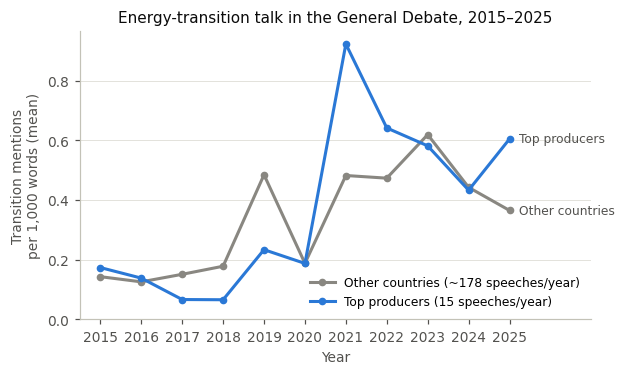

top_producer,False,True
Year,,
2015,0.143,0.173
2016,0.125,0.138
2017,0.151,0.066
2018,0.178,0.065
2019,0.485,0.233
2020,0.188,0.187
2021,0.482,0.924
2022,0.473,0.642
2023,0.620,0.582


In [11]:
trend = df.groupby(['Year', 'top_producer'])['mentions_per_1000_words'].mean().unstack()
n_per_year = df.groupby(['Year', 'top_producer']).size().unstack()

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(trend.index, trend[False], color=CONTEXT, marker='o', ms=4,
        label=f'Other countries (~{n_per_year[False].mean():.0f} speeches/year)')
ax.plot(trend.index, trend[True], color=ACCENT, marker='o', ms=4,
        label=f'Top producers ({n_per_year[True].mean():.0f} speeches/year)')

last = trend.index.max()
ax.annotate('Other countries', (last, trend.loc[last, False]), xytext=(6, 0), textcoords='offset points',
            va='center', fontsize=8, color=INK_SECONDARY)
ax.annotate('Top producers', (last, trend.loc[last, True]), xytext=(6, 0), textcoords='offset points',
            va='center', fontsize=8, color=INK_SECONDARY)

ax.set_xticks(trend.index)
ax.set_xlim(trend.index.min() - 0.5, last + 2)
ax.set_ylim(0, None)
ax.set_xlabel('Year')
ax.set_ylabel('Transition mentions\nper 1,000 words (mean)')
ax.set_title('Energy-transition talk in the General Debate, 2015–2025')
ax.legend(loc='lower right', fontsize=8)

save_fig(fig, 'fig2_talk_over_time')
plt.show()

trend.round(3)

Transition talk was rare until 2018 and rose sharply from 2019 onwards, peaking for the top producers in 2021 (the year
of COP26 in Glasgow). Over the whole period the top producers talk about the transition about as much as other
countries. Note that each yearly mean for the top producers is based on only 15 speeches, so single years are noisy.

## Step 6 — Country-level summary

One row per selected country:
- **mean_mentions_per_1000**: mean transition talk over all its speeches since 2015
- **share_first / share_last**: fossil share in the first and last year with data (2015 and 2025, except Iraq)
- **change_pp**: `share_last − share_first`, in percentage points
- **slope_pp_per_year**: slope of a straight line fitted through all yearly fossil-share values. This is our main
  outcome because it uses every year, not just the two end points, so a single unusual year matters less.

In [12]:
share_panel = (panel[panel['iso3'].isin(top_iso3) & (panel['Year'] >= PERIOD_START)]
               .dropna(subset=['fossil_share_pct'])
               .sort_values(['iso3', 'Year']))

rows = []
for iso, g in share_panel.groupby('iso3'):
    talk = top[top['iso3'] == iso]
    rows.append({
        'iso3': iso,
        'country': names[iso],
        'speeches': len(talk),
        'total_mentions': talk['transition_mention_count'].sum(),
        'mean_mentions_per_1000': talk['mentions_per_1000_words'].mean(),
        'first_year': g['Year'].iloc[0],
        'last_year': g['Year'].iloc[-1],
        'share_first': g['fossil_share_pct'].iloc[0],
        'share_last': g['fossil_share_pct'].iloc[-1],
        'slope_pp_per_year': np.polyfit(g['Year'], g['fossil_share_pct'], 1)[0],
    })

country_summary = pd.DataFrame(rows).set_index('iso3')
country_summary['change_pp'] = country_summary['share_last'] - country_summary['share_first']
country_summary = country_summary.sort_values('mean_mentions_per_1000', ascending=False)

country_summary.to_csv(f'{PREP_DIR}/eda_rq1_country_summary.csv')
country_summary.round(2)

,country,speeches,total_mentions,mean_mentions_per_1000,first_year,last_year,share_first,share_last,slope_pp_per_year,change_pp
iso3,,,,,,,,,,
BRA,Brazil,11,25,1.10,2015,2025,72.34,62.32,-0.93,-10.03
AUS,Australia,11,27,1.03,2015,2025,97.06,92.11,-0.53,-4.94
NOR,Norway,11,14,0.73,2015,2025,54.04,46.91,-0.71,-7.13
KAZ,Kazakhstan,11,15,0.69,2015,2025,98.48,98.07,-0.04,-0.41
ARE,United Arab Emirates,11,9,0.44,2015,2025,99.98,90.47,-1.13,-9.50
ZAF,South Africa,11,8,0.38,2015,2025,96.79,95.27,-0.10,-1.52
IDN,Indonesia,11,4,0.29,2015,2025,93.63,88.32,-0.60,-5.31
SAU,Saudi Arabia,11,6,0.24,2015,2025,100.00,99.41,-0.04,-0.59
QAT,Qatar,11,5,0.23,2015,2025,99.94,99.37,-0.05,-0.56


## Step 7 — Fossil-fuel share trajectories

**Figure 3.** Change in fossil share since the first year with data (percentage points), one panel per country. The
panels are ordered by how much the country talks about the transition (most talk top-left), and every panel uses the
same y-axis so the size of the changes can be compared directly.

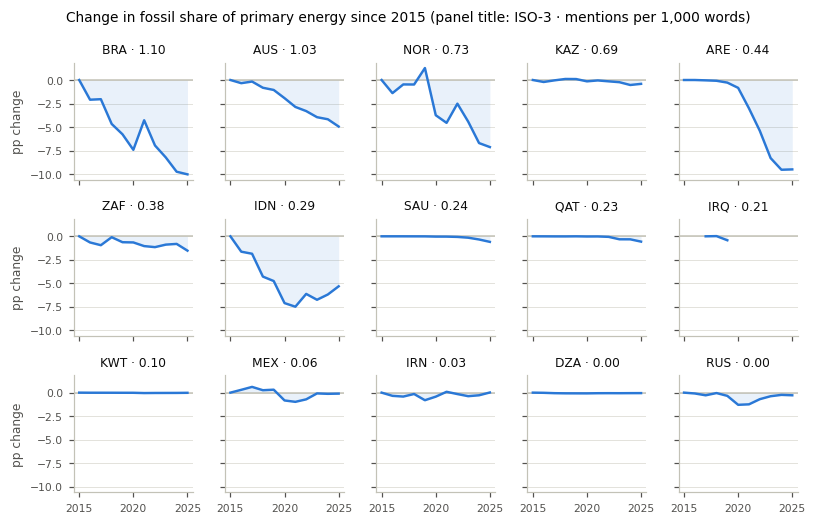

In [13]:
fig, axes = plt.subplots(3, 5, figsize=(7.5, 4.8), sharex=True, sharey=True)

for ax, iso in zip(axes.flat, country_summary.index):
    g = share_panel[share_panel['iso3'] == iso]
    change = g['fossil_share_pct'] - g['fossil_share_pct'].iloc[0]
    ax.axhline(0, color=AXIS, lw=1)
    ax.fill_between(g['Year'], change, 0, color=ACCENT, alpha=0.1, lw=0)
    ax.plot(g['Year'], change, color=ACCENT, lw=1.6)
    ax.set_title(f"{iso} · {country_summary.loc[iso, 'mean_mentions_per_1000']:.2f}", fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes[-1]:
    ax.set_xticks([2015, 2020, 2025])
for ax in axes[:, 0]:
    ax.set_ylabel('pp change', fontsize=8)

fig.suptitle('Change in fossil share of primary energy since 2015 '
             '(panel title: ISO-3 · mentions per 1,000 words)', fontsize=9)
fig.tight_layout()

save_fig(fig, 'fig3_fossil_share_trajectories')
plt.show()

The pattern is already visible: the countries in the top row (Brazil, Australia, Norway, Kazakhstan, UAE) talk the
most, and all except Kazakhstan cut their fossil share by 5–10 percentage points. The bottom row (Algeria, Russia,
Iran, Mexico, Kuwait) hardly ever mentions the transition and their fossil share barely moved.

## Step 8 — Between-country correlation (main result)

**Figure 4.** Each point is one country: its mean transition talk (x) against the trend in its fossil share (y).
A negative correlation means that countries that talk more about the transition reduced their fossil share faster.

In [14]:
x = country_summary['mean_mentions_per_1000']
y = country_summary['slope_pp_per_year']

rho, p_rho = stats.spearmanr(x, y)
r, p_r = stats.pearsonr(x, y)
print(f'Spearman rho = {rho:.3f} (p = {p_rho:.4f}), n = {len(x)}')
print(f'Pearson  r   = {r:.3f} (p = {p_r:.4f})  [for reference only]')

Spearman rho = -0.745 (p = 0.0014), n = 15
Pearson  r   = -0.653 (p = 0.0084)  [for reference only]


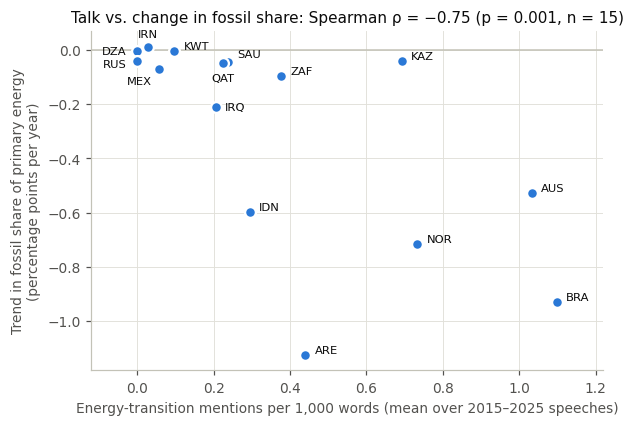

In [15]:
# Label offsets (in points) to keep the labels in the crowded bottom-left corner readable
label_pos = {
    'DZA': (-7, 0, 'right'), 'RUS': (-7, -2, 'right'), 'IRN': (0, 8, 'center'), 'KWT': (6, 3, 'left'),
    'MEX': (-5, -8, 'right'), 'SAU': (6, 5, 'left'), 'QAT': (0, -10, 'center'), 'IRQ': (6, 0, 'left'),
}

fig, ax = plt.subplots(figsize=(6, 4))
ax.grid(True, axis='both')
ax.axhline(0, color=AXIS, lw=1, zorder=1)
ax.scatter(x, y, s=50, color=ACCENT, edgecolor='white', linewidth=1.5, zorder=3)
for iso in country_summary.index:
    dx, dy, ha = label_pos.get(iso, (6, 3, 'left'))
    ax.annotate(iso, (x[iso], y[iso]), xytext=(dx, dy), textcoords='offset points',
                fontsize=7.5, ha=ha, va='center', color=INK)

ax.set_xlim(-0.12, x.max() + 0.12)

ax.set_xlabel('Energy-transition mentions per 1,000 words (mean over 2015–2025 speeches)')
ax.set_ylabel('Trend in fossil share of primary energy\n(percentage points per year)')
ax.set_title(f'Talk vs. change in fossil share: Spearman ρ = {rho:.2f} (p = {p_rho:.3f}, n = {len(x)})'
             .replace('-', '−'))

save_fig(fig, 'fig4_talk_vs_fossil_share')
plt.show()

### Robustness checks

With only 15 countries, one country could drive the result. We therefore check:
1. a different outcome definition (change between first and last year instead of the slope),
2. excluding Iraq, whose trend is based on only three years,
3. leave-one-out: recompute ρ 15 times, each time without one country.

In [16]:
def spearman_row(label, a, b):
    res = stats.spearmanr(a, b)
    return {'check': label, 'n': len(a), 'spearman_rho': res.statistic, 'p_value': res.pvalue}


no_irq = country_summary.drop(index='IRQ')
robustness = pd.DataFrame([
    spearman_row('Main: slope (pp/year)', x, y),
    spearman_row('Change first -> last year (pp)', x, country_summary['change_pp']),
    spearman_row('Slope, excluding Iraq', no_irq['mean_mentions_per_1000'], no_irq['slope_pp_per_year']),
])

loo = pd.DataFrame([
    spearman_row(f'without {iso}', x.drop(iso), y.drop(iso)) for iso in country_summary.index
]).set_index('check')

print(robustness.round(4).to_string(index=False))
print()
print(f"Leave-one-out: rho between {loo['spearman_rho'].min():.3f} and {loo['spearman_rho'].max():.3f}, "
      f"largest p = {loo['p_value'].max():.4f} ({loo['p_value'].idxmax()})")

                         check  n  spearman_rho  p_value
         Main: slope (pp/year) 15       -0.7453   0.0014
Change first -> last year (pp) 15       -0.8329   0.0001
         Slope, excluding Iraq 14       -0.7569   0.0017

Leave-one-out: rho between -0.832 and -0.704, largest p = 0.0049 (without BRA)


## Step 9 — Within-country (year-to-year) check

Step 8 compares countries with each other: over the whole period, the countries that talk more are the ones whose
fossil share fell faster. That does not mean that **in a given year** a country that talks more than usual also cuts
its fossil share more than usual. We test that separately:

- For every selected country and year, compute the change in fossil share compared to the previous year.
- Remove each country's own average (so only a country's deviation from its normal level is left). In a second
  version we also remove each year's average, so that shocks that hit every country at once (e.g. COVID-19 in 2020)
  do not create a correlation.
- Correlate transition talk with the change in fossil share in the **same** year and in the **next** year (the General
  Debate takes place in September, so any effect on energy use would more likely show up the following year).

In [17]:
yearly = top.dropna(subset=['fossil_share_pct']).sort_values(['iso3', 'Year']).copy()
assert yearly.groupby('iso3')['Year'].diff().dropna().eq(1).all()  # no gaps between years

yearly['share_change_same_year'] = yearly.groupby('iso3')['fossil_share_pct'].diff()
yearly['share_change_next_year'] = yearly.groupby('iso3')['share_change_same_year'].shift(-1)


def remove_country_effect(d, col):
    return d[col] - d.groupby('iso3')[col].transform('mean')


def remove_country_and_year_effect(d, col):
    return (d[col] - d.groupby('iso3')[col].transform('mean')
            - d.groupby('Year')[col].transform('mean') + d[col].mean())


rows = []
for outcome in ['share_change_same_year', 'share_change_next_year']:
    d = yearly.dropna(subset=[outcome])
    for label, adjust in [('country', remove_country_effect),
                          ('country + year', remove_country_and_year_effect)]:
        res = stats.spearmanr(adjust(d, 'mentions_per_1000_words'), adjust(d, outcome))
        rows.append({'outcome': outcome, 'removed averages': label, 'n': len(d),
                     'spearman_rho': res.statistic, 'p_value': res.pvalue})

within = pd.DataFrame(rows)
within.round(4)

,outcome,removed averages,n,spearman_rho,p_value
0,share_change_same_year,country,142,-0.0389,0.6455
1,share_change_same_year,country + year,142,0.0151,0.8580
2,share_change_next_year,country,142,-0.1881,0.0250
3,share_change_next_year,country + year,142,-0.2373,0.0045


- **Same year:** no relationship (ρ ≈ 0). In years when a country talks more than it usually does, its fossil share
  does not fall faster in that same year.
- **Next year:** a weak negative relationship (ρ ≈ −0.2, p < 0.05). This is much weaker than the between-country
  correlation, and the p-values should be read with care: the 142 observations are repeated measurements of the same
  15 countries (so not independent), and we ran four tests.

So the strong relationship in RQ1 is mainly a difference **between countries** (countries that talk more have been
moving away from fossil fuels faster), with at most a weak link from one year's speech to the next year's change.

## Step 10 — Summary

1. **Selection.** 19 countries are in the top quartile for fossil-fuel production and 51 for fossil rents (% of GDP).
   The 15 countries in both groups are our top fossil-fuel producers. China, the US, Canada and India are large
   producers but are excluded because their economies are not rent-dependent.
2. **Transition talk is rare.** About two in three speeches never mention the energy transition (median 0 mentions).
   Talk rose sharply from 2019 onwards (for the top producers it peaked in 2021); over the whole period the top
   producers talk about it about as much as other countries (0.37 vs. 0.33 mentions per 1,000 words).
3. **Main result (between countries).** Among the 15 top producers, the countries that talked more about the energy
   transition reduced the fossil share of their energy mix faster: Spearman ρ = −0.75 (p = 0.001, n = 15) with the
   slope as outcome and ρ = −0.83 (p < 0.001) with the first-to-last-year change. The result holds without Iraq and
   when any single country is left out.
4. **Not a same-year link.** Within countries, talking more than usual in a given year is not related to a larger
   drop in fossil share that year, and only weakly (ρ ≈ −0.2) to the next year's change.
5. **Caveats.** Only 15 countries, so this is a correlation, not a causal effect. Countries also start from very
   different levels (Norway and Brazil already have a large hydropower share). The fossil share measures the
   **consumption** side of the energy system, not how much a country **produces**.

**How this refines the predictive question (RQ2).** Transition talk goes together with a lower fossil share of a
country's own energy **consumption**. The natural next question is whether talk also says something about fossil-fuel
**production**, which is what matters most for these countries' economies. RQ2 therefore asks whether how often and how
cautiously a country talks about the transition predicts the change in its fossil-fuel production.